<a href="https://colab.research.google.com/github/ThisumiWijesinghe/Fraud-Detection-with-Federated-Learning/blob/main/AI_Project_New.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


Load & Preprocess Dataset

In [ ]:
import kagglehub

# Download dataset from Kaggle
path = kagglehub.dataset_download("ealaxi/paysim1")

# Define file path
file_path = path + "/PS_20174392719_1491204439457_log.csv"

# Load dataset
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)


# Encode categorical column
le = LabelEncoder()
df["type"] = le.fit_transform(df["type"])

# Select features
features = ["step", "type", "amount",
            "oldbalanceOrg", "newbalanceOrig",
            "oldbalanceDest", "newbalanceDest"]

X = df[features].values
y = df["isFraud"].values

INPUT_DIM = X.shape[1]


100%|██████████| 178M/178M [00:01<00:00, 125MB/s]

Extracting files...


Dataset shape: (6362620, 11)


Create Non-IID Split (Dirichlet Distribution)

In [ ]:
NUM_CLIENTS = 12
alpha = 0.5

def dirichlet_split(X, y, num_clients, alpha):
    data_per_client = [[] for _ in range(num_clients)]
    labels = np.unique(y)
    for label in labels:
        idx = np.where(y == label)[0]
        np.random.shuffle(idx)
        proportions = np.random.dirichlet(np.repeat(alpha, num_clients))
        proportions = (np.cumsum(proportions) * len(idx)).astype(int)[:-1]
        split_idx = np.split(idx, proportions)
        for i in range(num_clients):
            data_per_client[i].extend(split_idx[i])

    clients_data = {}
    for i in range(num_clients):
        client_idx = data_per_client[i]
        clients_data[i] = {"X": X[client_idx], "y": y[client_idx]}
    return clients_data

raw_clients_data = dirichlet_split(X, y, NUM_CLIENTS, alpha)


In [ ]:
# make Train/Test split for each bank
clients_final_data = {}
for i in range(NUM_CLIENTS):
    X_c, y_c = raw_clients_data[i]["X"], raw_clients_data[i]["y"]
    X_train, X_test, y_train, y_test = train_test_split(X_c, y_c, test_size=0.2, random_state=42)
    clients_final_data[i] = {"X_train": X_train, "y_train": y_train, "X_test": X_test, "y_test": y_test}

print("✅ Each bank now has separate Train (80%) and Test (20%) sets.")

✅ Each bank now has separate Train (80%) and Test (20%) sets.


In [ ]:
# ---  Model Architecture ---
def create_model():
    model = tf.keras.Sequential([
        layers.Input(shape=(INPUT_DIM,)),
        layers.Dense(64, activation="relu"),
        layers.BatchNormalization(),
        layers.Dense(32, activation="relu"),
        layers.BatchNormalization(),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
def analyze_clients(data_to_analyze):
    print("\nClient Data Distribution (Total Data):\n")
    for client_id in data_to_analyze:
        X_client = data_to_analyze[client_id]["X"]
        y_client = data_to_analyze[client_id]["y"]

        total_samples = len(y_client)
        fraud_samples = np.sum(y_client == 1)
        nonfraud_samples = np.sum(y_client == 0)
        fraud_percentage = (fraud_samples / total_samples) * 100

        print(f"Client {client_id+1}")
        print(f"   Total Samples     : {total_samples}")
        print(f"   Fraud Samples     : {fraud_samples}")
        print(f"   Non-Fraud Samples : {nonfraud_samples}")
        print(f"   Fraud %           : {fraud_percentage:.4f}%")
        print("-" * 40)

analyze_clients(raw_clients_data)


Client Data Distribution (Total Data):

Client 1
   Total Samples     : 11580
   Fraud Samples     : 126
   Non-Fraud Samples : 11454
   Fraud %           : 1.0881%
----------------------------------------
Client 2
   Total Samples     : 13265
   Fraud Samples     : 2025
   Non-Fraud Samples : 11240
   Fraud %           : 15.2657%
----------------------------------------
Client 3
   Total Samples     : 28412
   Fraud Samples     : 724
   Non-Fraud Samples : 27688
   Fraud %           : 2.5482%
----------------------------------------
Client 4
   Total Samples     : 98788
   Fraud Samples     : 820
   Non-Fraud Samples : 97968
   Fraud %           : 0.8301%
----------------------------------------
Client 5
   Total Samples     : 650780
   Fraud Samples     : 83
   Non-Fraud Samples : 650697
   Fraud %           : 0.0128%
----------------------------------------
Client 6
   Total Samples     : 60459
   Fraud Samples     : 6
   Non-Fraud Samples : 60453
   Fraud %           : 0.0099%
---

Local Training (without FL)

In [ ]:
import tensorflow as tf

def create_model(input_dim):

    model = tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation='relu', input_shape=(input_dim,)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


In [ ]:
NUM_CLIENTS = 12
LOCAL_EPOCHS = 5
BATCH_SIZE = 2048

client_models_noFL = []

print("\nTraining models WITHOUT Federated Learning\n")

for client_id in range(NUM_CLIENTS):
    print(f"Training Client {client_id+1} model...")

    # get data
    X_client = raw_clients_data[client_id]["X"]
    y_client = raw_clients_data[client_id]["y"]


    model = create_model(X_client.shape[1])

    model.fit(
        X_client,
        y_client,
        epochs=LOCAL_EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0
    )

    client_models_noFL.append(model)

print("\n✅ Training completed successfully!")


Training models WITHOUT Federated Learning

Training Client 1 model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Client 2 model...
Training Client 3 model...
Training Client 4 model...
Training Client 5 model...
Training Client 6 model...
Training Client 7 model...
Training Client 8 model...
Training Client 9 model...
Training Client 10 model...
Training Client 11 model...
Training Client 12 model...

✅ Training completed successfully!


In [ ]:
print("\nEvaluating Fraud Detection Accuracy (No FL)\n")

total_acc = 0

for client_id in range(NUM_CLIENTS):

    X_test = clients_final_data[client_id]["X_test"]
    y_test = clients_final_data[client_id]["y_test"]

    loss, acc = client_models_noFL[client_id].evaluate(
        X_test,
        y_test,
        verbose=0
    )

    print(f"Client {client_id+1} Fraud Detection Accuracy: {acc:.4f}")

    total_acc += acc

print("\nAverage Accuracy (No Federated Learning):", total_acc/NUM_CLIENTS)


Evaluating Fraud Detection Accuracy (No FL)

Client 1 Fraud Detection Accuracy: 0.9352
Client 2 Fraud Detection Accuracy: 0.8918
Client 3 Fraud Detection Accuracy: 0.9817
Client 4 Fraud Detection Accuracy: 0.9956
Client 5 Fraud Detection Accuracy: 0.9999
Client 6 Fraud Detection Accuracy: 0.9993
Client 7 Fraud Detection Accuracy: 0.9998
Client 8 Fraud Detection Accuracy: 1.0000
Client 9 Fraud Detection Accuracy: 0.9944
Client 10 Fraud Detection Accuracy: 0.9830
Client 11 Fraud Detection Accuracy: 0.9999
Client 12 Fraud Detection Accuracy: 0.9999

Average Accuracy (No Federated Learning): 0.9817331184943517


Create Model (Used for FedAvg & FedBN)

In [ ]:
def create_model():
    model = tf.keras.Sequential([
        layers.Input(shape=(INPUT_DIM,)),
        layers.Dense(64, activation="relu"),
        layers.BatchNormalization(),
        layers.Dense(32, activation="relu"),
        layers.BatchNormalization(),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model


FedAvg Aggregation

In [ ]:
def fedavg_aggregate(client_weights):
    new_weights = []
    for weights in zip(*client_weights):
        new_weights.append(np.mean(weights, axis=0))
    return new_weights


In [ ]:
#Accuracy Evaluation
def evaluate_accuracy(model, clients_data):
    total_acc = 0
    for client_id in clients_data:
        loss, acc = model.evaluate(
            clients_data[client_id]["X"],
            clients_data[client_id]["y"],
            verbose=0
        )
        print(f"Client {client_id+1} Accuracy: {acc:.4f}")
        total_acc += acc

    print(f"Average Accuracy: {total_acc/len(clients_data):.4f}\n")


Federated Training Loop (FedAvg Example)

In [ ]:
NUM_ROUNDS = 20
LOCAL_EPOCHS = 5
BATCH_SIZE = 1024

# global_model = create_model(INPUT_DIM)
global_model = create_model()

for round_num in range(NUM_ROUNDS):
    print(f"--- Global Round {round_num+1} ---")

    client_weights = []

    for client_id in range(NUM_CLIENTS):

        local_model = create_model()
        local_model.set_weights(global_model.get_weights())


        local_model.fit(
            clients_final_data[client_id]["X_train"],
            clients_final_data[client_id]["y_train"],
            epochs=LOCAL_EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=0
        )

        client_weights.append(local_model.get_weights())

    # Server Aggregation
    new_weights = fedavg_aggregate(client_weights)
    global_model.set_weights(new_weights)

    # Evaluate

    print(f"Round {round_num+1} aggregation completed.")

--- Global Round 1 ---
Round 1 aggregation completed.
--- Global Round 2 ---
Round 2 aggregation completed.
--- Global Round 3 ---
Round 3 aggregation completed.
--- Global Round 4 ---
Round 4 aggregation completed.
--- Global Round 5 ---
Round 5 aggregation completed.
--- Global Round 6 ---
Round 6 aggregation completed.
--- Global Round 7 ---
Round 7 aggregation completed.
--- Global Round 8 ---
Round 8 aggregation completed.
--- Global Round 9 ---
Round 9 aggregation completed.
--- Global Round 10 ---
Round 10 aggregation completed.
--- Global Round 11 ---
Round 11 aggregation completed.
--- Global Round 12 ---
Round 12 aggregation completed.
--- Global Round 13 ---
Round 13 aggregation completed.
--- Global Round 14 ---
Round 14 aggregation completed.
--- Global Round 15 ---
Round 15 aggregation completed.
--- Global Round 16 ---
Round 16 aggregation completed.
--- Global Round 17 ---
Round 17 aggregation completed.
--- Global Round 18 ---
Round 18 aggregation completed.
--- Global

In [ ]:
print("\nEvaluating Final Global Model (FedAvg) on Test Data:\n")

fedavg_final_acc = []
total_acc = 0

for client_id in range(NUM_CLIENTS):
    # Unseen test data
    X_test = clients_final_data[client_id]["X_test"]
    y_test = clients_final_data[client_id]["y_test"]

    loss, acc = global_model.evaluate(X_test, y_test, verbose=0)

    print(f"Bank {client_id+1} Accuracy: {acc:.4f}")

    fedavg_final_acc.append(acc)
    total_acc += acc

print(f"\nAverage FedAvg Accuracy: {total_acc/NUM_CLIENTS:.4f}")


Evaluating Final Global Model (FedAvg) on Test Data:

Bank 1 Accuracy: 0.9918
Bank 2 Accuracy: 0.8960
Bank 3 Accuracy: 0.9840
Bank 4 Accuracy: 0.9943
Bank 5 Accuracy: 0.9999
Bank 6 Accuracy: 0.9998
Bank 7 Accuracy: 0.9999
Bank 8 Accuracy: 1.0000
Bank 9 Accuracy: 0.9915
Bank 10 Accuracy: 0.9753
Bank 11 Accuracy: 0.9999
Bank 12 Accuracy: 0.9999

Average FedAvg Accuracy: 0.9860


FedBN Aggregation

In [ ]:
def fedbn_aggregate(client_weights, global_model):
    new_weights = global_model.get_weights()

    # Identify BatchNorm layers
    bn_layers = []
    for i, layer in enumerate(global_model.layers):
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            bn_layers.append(i)

    # Go through each layer's weights
    weight_index = 0
    for layer_idx, layer in enumerate(global_model.layers):
        layer_weights = layer.get_weights()
        num_weights = len(layer_weights)

        if num_weights == 0:
            continue

        # If not BatchNorm → average normally
        if layer_idx not in bn_layers:
            averaged = []
            for weights in zip(*[client_weights[c][weight_index:weight_index+num_weights]
                                 for c in range(len(client_weights))]):
                averaged.append(np.mean(weights, axis=0))

            new_weights[weight_index:weight_index+num_weights] = averaged

        # Move weight index
        weight_index += num_weights

    return new_weights


FedBN Training Loop

In [ ]:
# Parameters
num_rounds = 20
local_epochs = 5
batch_size = 512
num_clients = 12

# RAM එක බේරගන්න Data ටික එක පාරක් Convert කරමු
print("⏳ Preparing data...")
for i in range(num_clients):
    clients_final_data[i]["X_train"] = np.array(clients_final_data[i]["X_train"], dtype='float32')
    clients_final_data[i]["y_train"] = np.array(clients_final_data[i]["y_train"], dtype='float32')
    clients_final_data[i]["X_test"] = np.array(clients_final_data[i]["X_test"], dtype='float32')
    clients_final_data[i]["y_test"] = np.array(clients_final_data[i]["y_test"], dtype='float32')

# Models හදමු
global_fedbn_model = create_model()
client_models = [create_model() for _ in range(num_clients)]

# මුලින්ම ඔක්කොම models වලට global weights දාමු
initial_weights = global_fedbn_model.get_weights()
for model in client_models:
    model.set_weights(initial_weights)

print("✅ Setup Complete!")

⏳ Preparing data...
✅ Setup Complete!


In [ ]:
import gc

print("🚀 Starting Federated Training (FedBN)...\n")

for r in range(num_rounds):
    print(f"--- Global Round {r+1} ---")
    all_client_weights = []

    for client_id in range(num_clients):
        local_model = client_models[client_id]

        # 1. Sync Non-BN Weights from Global to Local
        sync_non_bn_weights(global_fedbn_model, local_model)

        # 2. Local Training
        local_model.fit(
            clients_final_data[client_id]["X_train"],
            clients_final_data[client_id]["y_train"],
            epochs=local_epochs,
            batch_size=batch_size,
            verbose=0,
            shuffle=True
        )

        all_client_weights.append(local_model.get_weights())

    # 3. Global Aggregation (Excluding BN layers)
    new_global_weights = fedbn_aggregate(all_client_weights, global_fedbn_model)
    global_fedbn_model.set_weights(new_global_weights)

    # 4. Evaluation
    evaluate_accuracy_fedbn(client_models, clients_final_data)
    gc.collect()

print("✅ Training Complete!")

🚀 Starting Federated Training (FedBN)...

--- Global Round 1 ---
Client 1 Accuracy: 0.9909
Client 2 Accuracy: 0.9393
Client 3 Accuracy: 0.9898
Client 4 Accuracy: 0.9950
Client 5 Accuracy: 0.9999
Client 6 Accuracy: 0.9998
Client 7 Accuracy: 0.9998
Client 8 Accuracy: 1.0000
Client 9 Accuracy: 0.9929
Client 10 Accuracy: 0.9869
Client 11 Accuracy: 0.9999
Client 12 Accuracy: 0.9999
Average Accuracy: 0.9912

--- Global Round 2 ---
Client 1 Accuracy: 0.9918
Client 2 Accuracy: 0.9295
Client 3 Accuracy: 0.9898
Client 4 Accuracy: 0.9958
Client 5 Accuracy: 0.9998
Client 6 Accuracy: 0.9998
Client 7 Accuracy: 0.9999
Client 8 Accuracy: 1.0000
Client 9 Accuracy: 0.9934
Client 10 Accuracy: 0.9837
Client 11 Accuracy: 0.9999
Client 12 Accuracy: 0.9999
Average Accuracy: 0.9903

--- Global Round 3 ---
Client 1 Accuracy: 0.9922
Client 2 Accuracy: 0.9329
Client 3 Accuracy: 0.9905
Client 4 Accuracy: 0.9954
Client 5 Accuracy: 0.9999
Client 6 Accuracy: 0.9998
Client 7 Accuracy: 0.9999
Client 8 Accuracy: 1.0000

In [ ]:
local_final_acc = []
fedavg_final_acc = []
fedbn_final_acc = []

print("\n📊 Collecting Final Results for Comparison...\n")

# 1. Local Training Accuracy (FL නැතුව තනි තනිව පුහුණු කළ models තියෙනවා නම්)
for client_id in range(num_clients):
    # client_models_noFL කියන models කලින් cell එකක හදලා තියෙන්න ඕනේ
    loss, acc = client_models_noFL[client_id].evaluate(
        clients_final_data[client_id]["X_test"],
        clients_final_data[client_id]["y_test"], verbose=0)
    local_final_acc.append(acc)

# 2. FedAvg Accuracy (Global model එකෙන්)
for client_id in range(num_clients):
    # global_model කියන එක FedAvg rounds වලින් පස්සේ තියෙන එක
    loss, acc = global_model.evaluate(
        clients_final_data[client_id]["X_test"],
        clients_final_data[client_id]["y_test"], verbose=0)
    fedavg_final_acc.append(acc)

# 3. FedBN Accuracy (දැන් අපි ඉවර කරපු Local models වලින්)
for client_id in range(num_clients):
    loss, acc = client_models[client_id].evaluate(
        clients_final_data[client_id]["X_test"],
        clients_final_data[client_id]["y_test"], verbose=0)
    fedbn_final_acc.append(acc)

print(f"✅ Comparison Data Collected.")
print(f"Average FedBN Accuracy: {np.mean(fedbn_final_acc):.4f}")


📊 Collecting Final Results for Comparison...

✅ Comparison Data Collected.
Average FedBN Accuracy: 0.9893


#Visualization Part

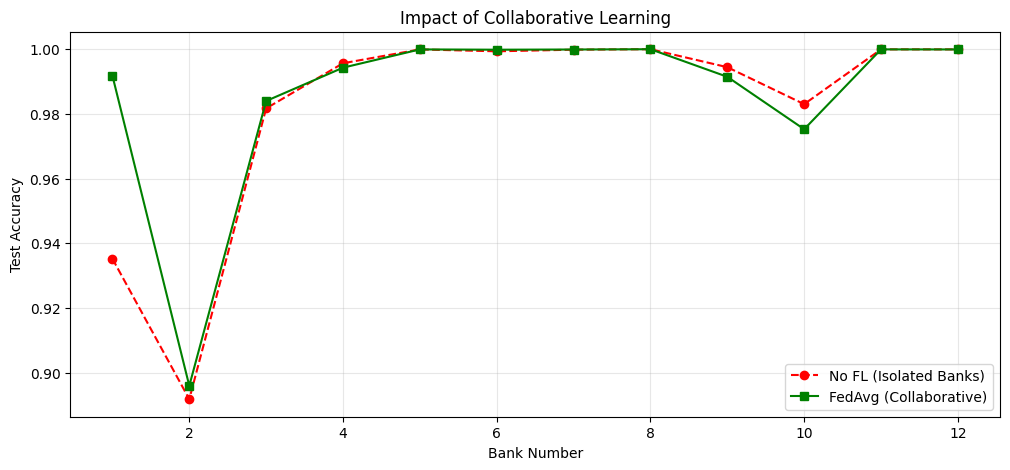

In [ ]:
import matplotlib.pyplot as plt

local_acc = [client_models_noFL[i].evaluate(clients_final_data[i]["X_test"], clients_final_data[i]["y_test"], verbose=0)[1] for i in range(12)]
fedavg_acc = [global_model.evaluate(clients_final_data[i]["X_test"], clients_final_data[i]["y_test"], verbose=0)[1] for i in range(12)]

plt.figure(figsize=(12, 5))
plt.plot(range(1, 13), local_acc, marker='o', label='No FL (Isolated Banks)', color='red', linestyle='--')
plt.plot(range(1, 13), fedavg_acc, marker='s', label='FedAvg (Collaborative)', color='green')
plt.title('Impact of Collaborative Learning')
plt.xlabel('Bank Number')
plt.ylabel('Test Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

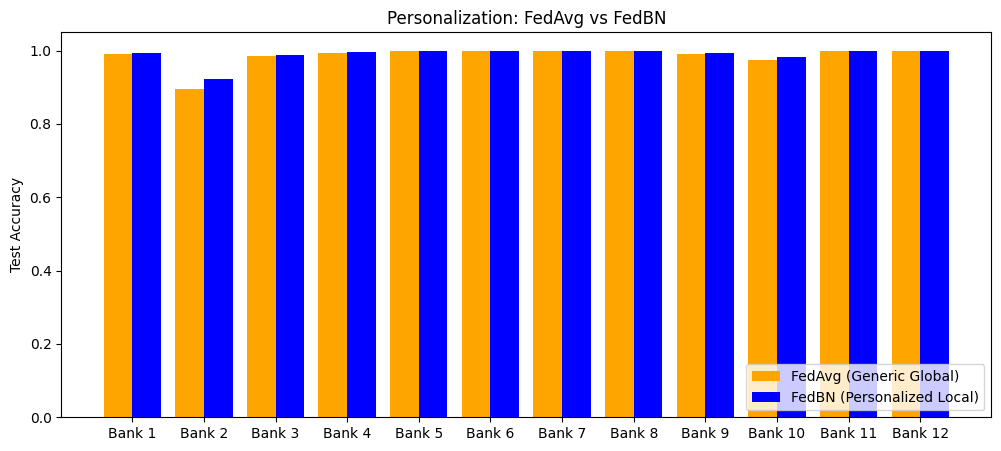

In [ ]:
fedbn_acc = [client_models[i].evaluate(clients_final_data[i]["X_test"], clients_final_data[i]["y_test"], verbose=0)[1] for i in range(12)]

plt.figure(figsize=(12, 5))
plt.bar(np.arange(12) - 0.2, fedavg_acc, 0.4, label='FedAvg (Generic Global)', color='orange')
plt.bar(np.arange(12) + 0.2, fedbn_acc, 0.4, label='FedBN (Personalized Local)', color='blue')
plt.xticks(np.arange(12), [f'Bank {i+1}' for i in range(12)])
plt.title('Personalization: FedAvg vs FedBN')
plt.ylabel('Test Accuracy')
plt.legend(loc='lower right')
plt.show()

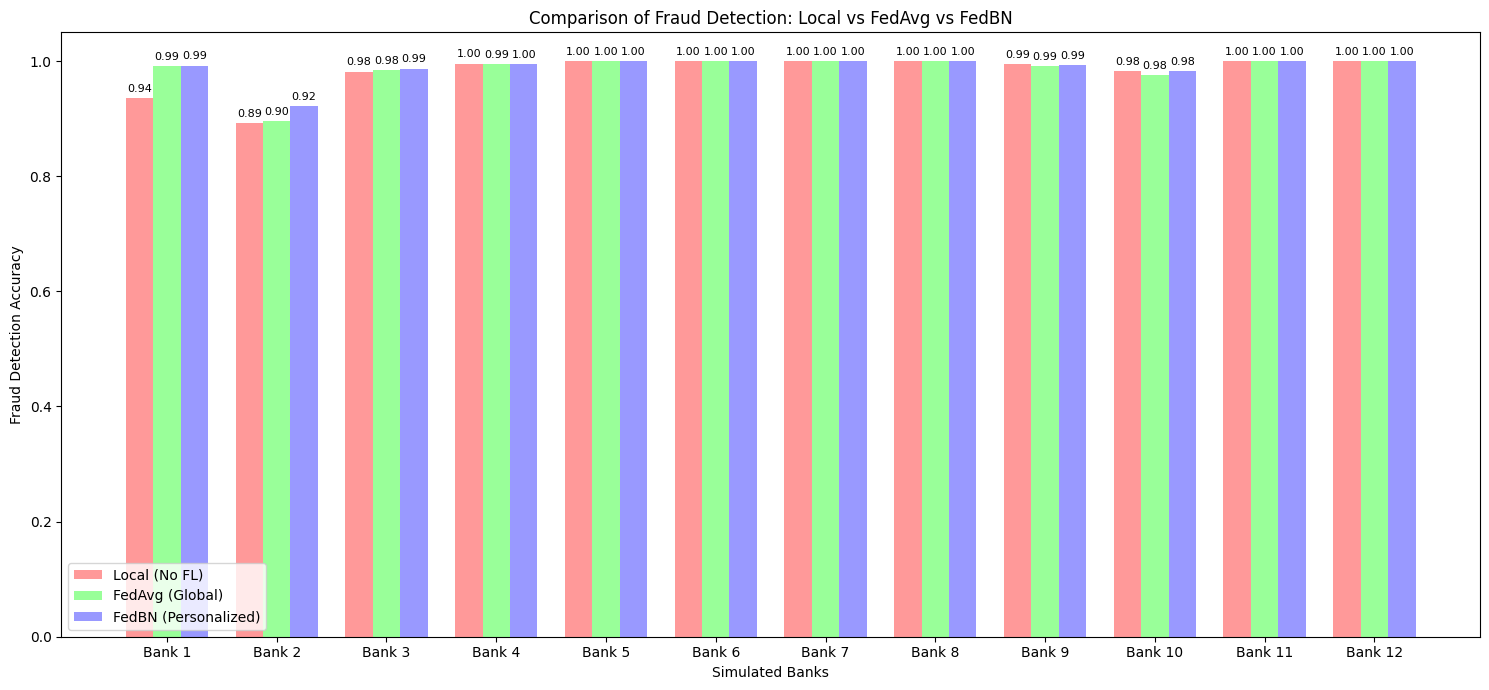

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data setup
banks = [f"Bank {i+1}" for i in range(NUM_CLIENTS)]
x = np.arange(len(banks))
width = 0.25

# Create Plot
fig, ax = plt.subplots(figsize=(15, 7))

rects1 = ax.bar(x - width, local_final_acc, width, label='Local (No FL)', color='#FF9999')
rects2 = ax.bar(x, fedavg_final_acc, width, label='FedAvg (Global)', color='#99FF99')
rects3 = ax.bar(x + width, fedbn_final_acc, width, label='FedBN (Personalized)', color='#9999FF')

# Labels & Titles
ax.set_xlabel('Simulated Banks')
ax.set_ylabel('Fraud Detection Accuracy')
ax.set_title('Comparison of Fraud Detection: Local vs FedAvg vs FedBN')
ax.set_xticks(x)
ax.set_xticklabels(banks)
ax.legend()

# Accuracy values bars in top
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.show()

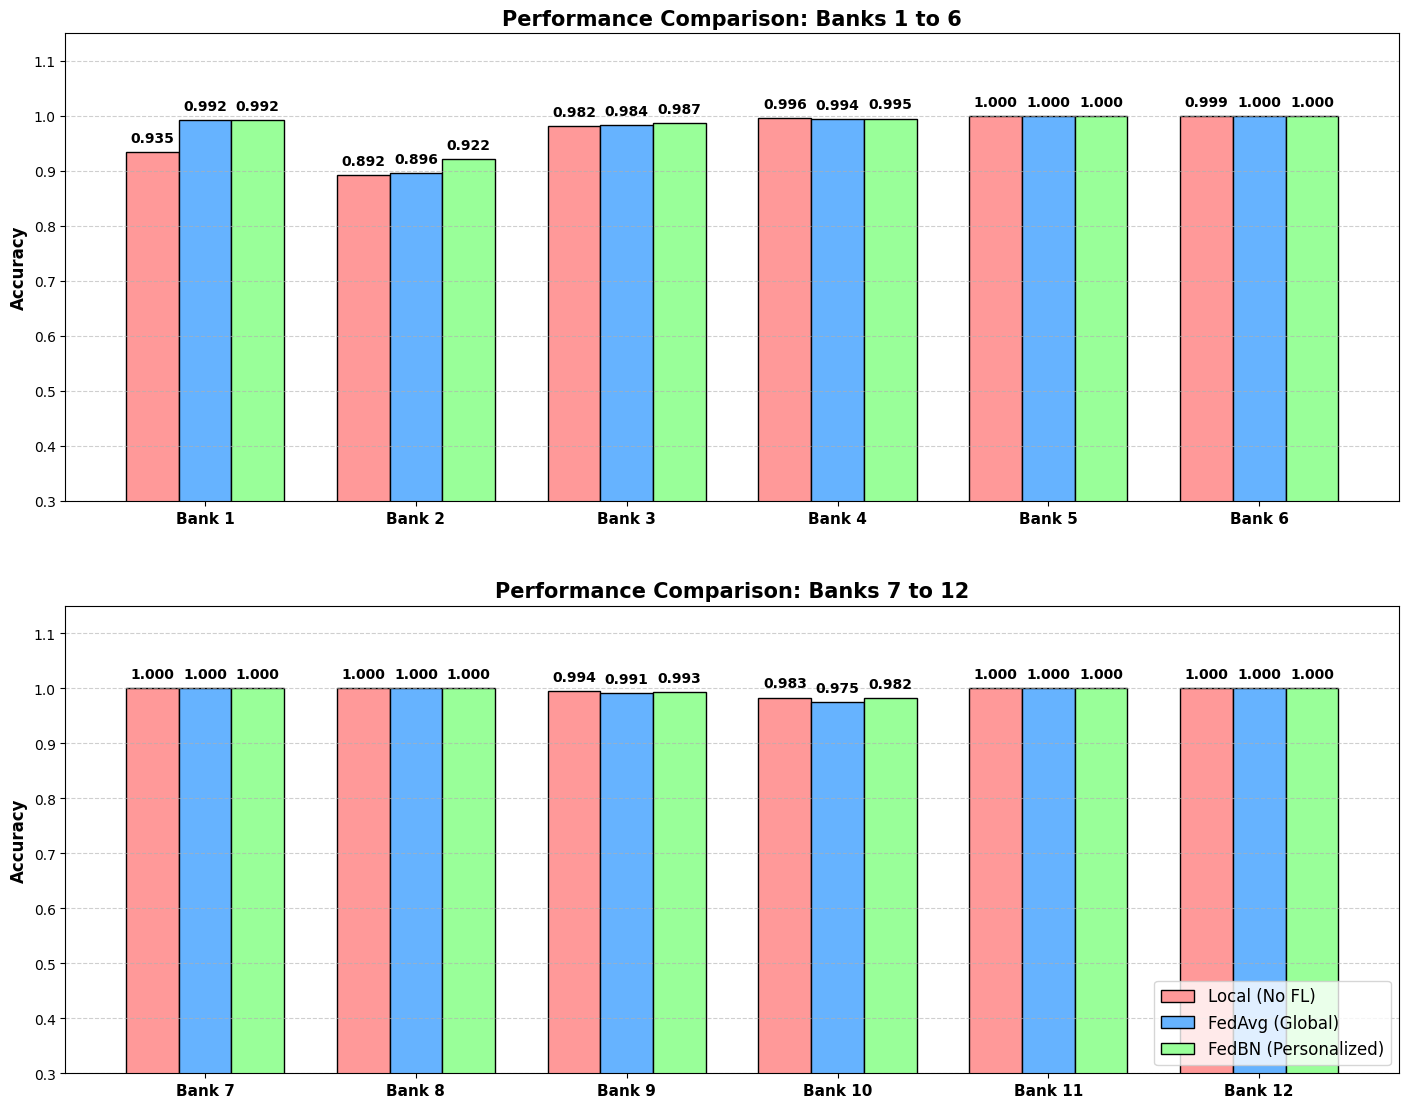

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# දත්ත කොටස් දෙකකට බෙදීම (Bank 1-6 සහ Bank 7-12)
bank_names = [f"Bank {i+1}" for i in range(len(fedbn_final_acc))]
data_sets = [
    (bank_names[:6], local_final_acc[:6], fedavg_final_acc[:6], fedbn_final_acc[:6]),
    (bank_names[6:], local_final_acc[6:], fedavg_final_acc[6:], fedbn_final_acc[6:])
]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12)) # Graphs දෙකක් එක යට එක
axes = [ax1, ax2]
width = 0.25

for i, (names, local, avg, bn) in enumerate(data_sets):
    x = np.arange(len(names))
    ax = axes[i]

    # Bars ඇඳීම
    ax.bar(x - width, local, width, label='Local (No FL)', color='#ff9999', edgecolor='black')
    ax.bar(x, avg, width, label='FedAvg (Global)', color='#66b3ff', edgecolor='black')
    ax.bar(x + width, bn, width, label='FedBN (Personalized)', color='#99ff99', edgecolor='black')

    # සැකසුම්
    ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(names, fontsize=11, fontweight='bold')
    ax.set_ylim(0.3, 1.15) # Zoom effect
    ax.yaxis.grid(True, linestyle='--', alpha=0.6)

    # අගයන් ලකුණු කිරීම (Labels)
    for rect in ax.patches:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5), textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, rotation=0, fontweight='bold')

ax1.set_title('Performance Comparison: Banks 1 to 6', fontsize=15, fontweight='bold')
ax2.set_title('Performance Comparison: Banks 7 to 12', fontsize=15, fontweight='bold')
ax2.legend(loc='lower right', fontsize=12)

plt.tight_layout(pad=4.0)
plt.show()

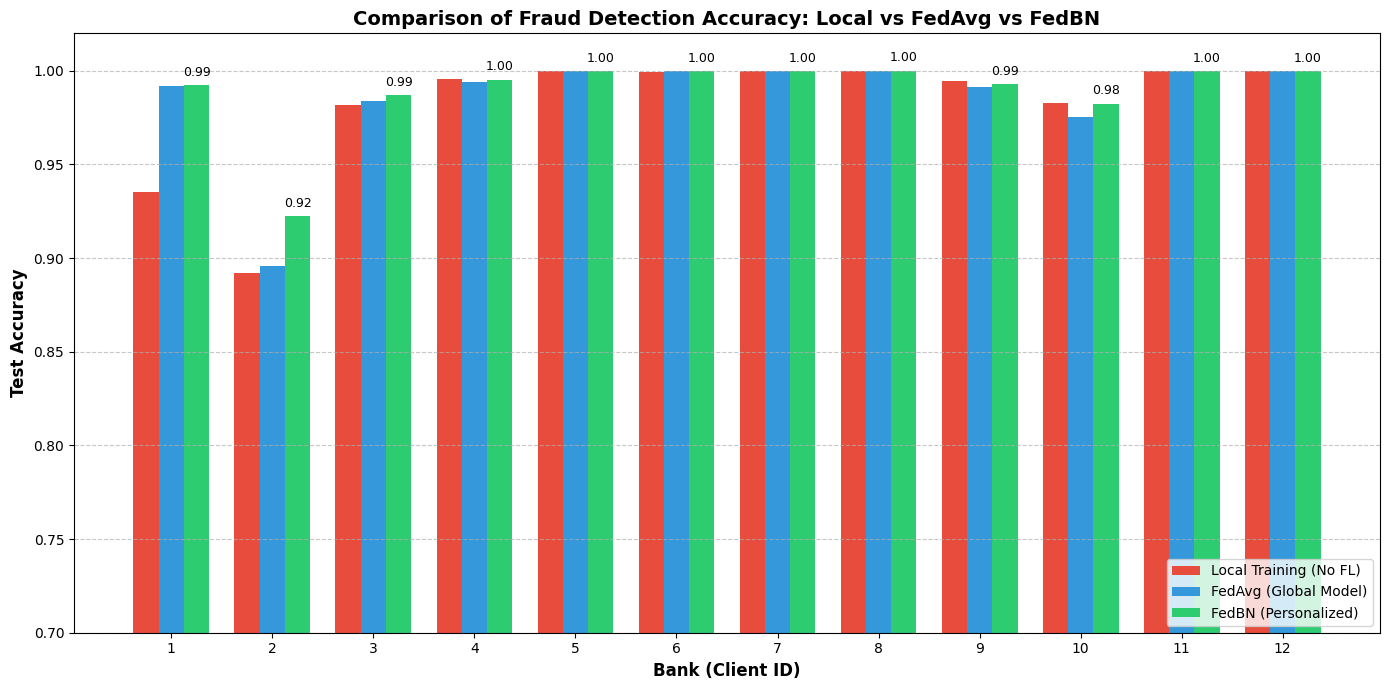

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# බැංකු අංක (1-12)
banks = np.arange(1, 13)
width = 0.25  # Bar එකක පළල

plt.figure(figsize=(14, 7))

# 1. Local Accuracy Bars
plt.bar(banks - width, local_final_acc, width, label='Local Training (No FL)', color='#e74c3c')

# 2. FedAvg Accuracy Bars
plt.bar(banks, fedavg_final_acc, width, label='FedAvg (Global Model)', color='#3498db')

# 3. FedBN Accuracy Bars
plt.bar(banks + width, fedbn_final_acc, width, label='FedBN (Personalized)', color='#2ecc71')

# Graph එකේ විස්තර
plt.xlabel('Bank (Client ID)', fontsize=12, fontweight='bold')
plt.ylabel('Test Accuracy', fontsize=12, fontweight='bold')
plt.title('Comparison of Fraud Detection Accuracy: Local vs FedAvg vs FedBN', fontsize=14, fontweight='bold')
plt.xticks(banks)
plt.ylim(0.7, 1.02) # Accuracy එක පැහැදිලිව පෙනෙන්න පරාසය සකස් කිරීම
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# අගයන් Bars වලට උඩින් පෙන්වීමට (Optional)
for i in range(len(banks)):
    plt.text(banks[i] + width, fedbn_final_acc[i] + 0.005, f'{fedbn_final_acc[i]:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# UI
client_dropdown = widgets.Dropdown(
    options=[(f'Bank {i+1}', i) for i in range(num_clients)],
    value=0,
    description='Select Bank:',
)

predict_button = widgets.Button(
    description='Predict Random Sample',
    button_style='success',
    icon='search'
)

output = widgets.Output()

def on_predict_clicked(b):
    with output:
        clear_output()

        selected_client = client_dropdown.value

        X_test = clients_final_data[selected_client]["X_test"]
        y_test = clients_final_data[selected_client]["y_test"]
        random_index = np.random.randint(0, len(X_test))

        sample = X_test[random_index:random_index+1]
        actual_label = y_test[random_index]


        # FedBN (Personalized Model)
        fedbn_pred = client_models[selected_client].predict(sample, verbose=0)[0][0]
        # FedAvg (Global Model)
        fedavg_pred = global_model.predict(sample, verbose=0)[0][0]

        print(f"🔍 Analyzing Random Transaction from Bank {selected_client + 1}...")
        print("-" * 50)
        print(f"✅ Actual Status: {'🚨 FRAUD' if actual_label == 1 else '🟢 NORMAL'}")
        print("-" * 50)
        print(f"🤖 FedBN Prediction:  {'🚨 FRAUD' if fedbn_pred > 0.5 else '🟢 NORMAL'} ({fedbn_pred*100:.2f}% Confidence)")
        print(f"🌍 FedAvg Prediction: {'🚨 FRAUD' if fedavg_pred > 0.5 else '🟢 NORMAL'} ({fedavg_pred*100:.2f}% Confidence)")
        print("-" * 50)

        if (fedbn_pred > 0.5) == actual_label:
            print("✨ FedBN Correctly Identified this!")
        else:
            print("⚠️ FedBN missed this one.")

predict_button.on_click(on_predict_clicked)

# Display the UI
print("📊 --- LIVE FRAUD DETECTION DEMO ---")
display(widgets.VBox([client_dropdown, predict_button, output]))

📊 --- LIVE FRAUD DETECTION DEMO ---
